In [7]:
from Helper.bigquery import Bigquery
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [9]:
# 1.  call the bigquery helper client and pull your clean data

bigquery_helper = Bigquery()
client = bigquery_helper.connect()

# 2. Pull your clean data from the Silver layer
query = """
    SELECT amount, item_category, days_to_first_purchase, is_returned
    FROM `project-5ef0b845-cbc9-4786-858.retail_silver.cleaned_transactions`
"""
df = client.query(query).to_dataframe()
print(df.head(5))

/home/HP/retail_folder/python_scripts/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


    amount item_category  days_to_first_purchase  is_returned
0   834.70       Apparel                       7        False
1    68.79       Apparel                      20         True
2   585.26       Apparel                      27        False
3   480.63       Apparel                       8         True
4  1119.88       Apparel                    <NA>        False


In [11]:
# 3. Basic Descriptive EDA
print(f"Total Rows Loaded: {df.shape[0]}")
print("####Summary Statistics######")
print(df[["amount", "days_to_first_purchase"]].describe())

print("####Item Category Distribution###")
print(df["item_category"].value_counts())

Total Rows Loaded: 9593
####Summary Statistics######
            amount  days_to_first_purchase
count  9593.000000                  8812.0
mean    606.220259               15.012937
std     342.772205                8.939249
min      10.530000                     0.0
25%     311.660000                     7.0
50%     608.400000                    15.0
75%     902.190000                    23.0
max    1199.880000                    30.0
####Item Category Distribution###
item_category
Automotive     1614
Sports         1608
Electronics    1607
Apparel        1605
Beauty         1604
Home           1555
Name: count, dtype: int64


In [13]:
cluster_data = pd.get_dummies(df[["amount", "item_category"]], drop_first=True)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_data)
print(scaled_features)

[[ 0.66659912 -0.44975659 -0.44808042 -0.44858349 -0.43983643 -0.44875114]
 [-1.56797507 -0.44975659 -0.44808042 -0.44858349 -0.43983643 -0.44875114]
 [-0.06115242 -0.44975659 -0.44808042 -0.44858349 -0.43983643 -0.44875114]
 ...
 [-1.4166422  -0.44975659 -0.44808042 -0.44858349 -0.43983643  2.22840661]
 [ 1.16783275 -0.44975659 -0.44808042 -0.44858349 -0.43983643  2.22840661]
 [-0.91485424 -0.44975659 -0.44808042 -0.44858349 -0.43983643  2.22840661]]


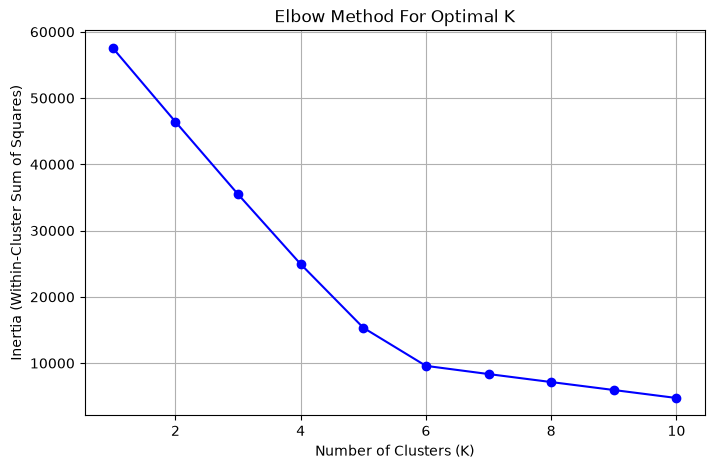

In [16]:
# 5. Run the Elbow Method to find optimal K
inertia = []
K_range = range(1, 11)

for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(scaled_features)
  inertia.append(kmeans.inertia_)  # Note the underscore here: inertia_

# 6. Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o", linestyle="-", color="b")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method For Optimal K")
plt.grid(True)
plt.show()